# Figure 2 synthetic peak-timing null analysis

This notebook is an **auditable synthetic positive-control benchmark**, not a real-data result. It tests whether a shape-agnostic coordination metric can recover known temporal structure from controlled synthetic archetype activations. Every activation profile, null replicate, p-value, figure, and pass/fail flag is computed by the notebook from declared parameters and random seeds.

The metric intentionally avoids the earlier full-profile zero-lag Pearson rule. Instead, it uses **peak timing**: for each archetype, the notebook finds the pseudotime position of maximum activation. It then asks whether archetypes peak in the expected order for sequential handoff systems, or within a narrow timing window for concurrent systems. This makes the test less dependent on whether an activation profile is sharp, gradual, sigmoid-like, or bell-shaped.

The notebook includes four requested synthetic systems: **System 1a**, a sharp step/plateau handoff; **System 1b**, a gradual sigmoid handoff; **System 2**, concurrent programs with varying overlap width; and **System 3**, smooth continuous no-structure controls. It also saves 100 × 50 × 50 Methods-scale synthetic tensors derived from the activations as a diagnostic artifact, but the positive-control claim is evaluated on the known synthetic archetype activations where the ground truth is declared.

In [2]:

from __future__ import annotations

import hashlib
import json
import math
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import kendalltau
import torch

# ── Paths (robust to local vs. server) ────────────────────────────────────
_here = Path.cwd().resolve()
if (_here / 'scjdo').exists():
    REPO = _here
elif (_here.parent / 'scjdo').exists():
    REPO = _here.parent
elif Path('/home/ubuntu/scJDO').exists():
    REPO = Path('/home/ubuntu/scJDO')
else:
    REPO = _here.parent

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from scjdo.archetypes.decompose import jacobian_modes

OUT    = REPO / 'Figures_notebook' / 'results' / 'Figure2_synthetic_peak_timing_null_analysis'
TABLES = OUT / 'tables'
FIGS   = OUT / 'figures'
for d in [OUT, TABLES, FIGS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Configuration ──────────────────────────────────────────────────────────
METHODS_N_WINDOWS  = 100
METHODS_N_PCS      = 50
RANK               = 5
N_SEEDS_PER_SYSTEM = 24
NULL_N_REPLICATES  = 200
GLOBAL_SEED        = 20260515
ALPHA              = 0.01
MINIMUM_P          = 1.0 / (1 + NULL_N_REPLICATES)
SEQUENTIAL_MIN_GAP = 0.055
CONCURRENT_MAX_GAP = 0.045
TENSOR_NOISE       = 0.010

sns.set_theme(style='whitegrid', context='paper')
mpl.rcParams.update({
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family': 'DejaVu Sans',
    'figure.dpi': 130, 'savefig.dpi': 600,
    'axes.titlesize': 9, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7,
})

SYSTEMS = [
    'system_1a_sharp_step_handoff',
    'system_1b_gradual_sigmoid_handoff',
    'system_2_concurrent_varying_overlap',
    'system_3_smooth_continuous_no_structure',
]

SYSTEM_METADATA = {
    'system_1a_sharp_step_handoff':          {'expected_signal': 'sequential',  'short': '1a sharp',   'description': 'Sharp step/plateau handoffs'},
    'system_1b_gradual_sigmoid_handoff':     {'expected_signal': 'sequential',  'short': '1b gradual', 'description': 'Gradual sigmoid handoffs'},
    'system_2_concurrent_varying_overlap':   {'expected_signal': 'concurrent',  'short': '2 concurr.', 'description': 'Concurrent Gaussian overlap'},
    'system_3_smooth_continuous_no_structure':{'expected_signal': 'none',       'short': '3 no struct','description': 'No-structure control'},
}

# Target metric per system for Figure 2c
TARGET_METRIC = {
    'system_1a_sharp_step_handoff':           'expected_order_pair_prevalence',
    'system_1b_gradual_sigmoid_handoff':      'expected_order_pair_prevalence',
    'system_2_concurrent_varying_overlap':    'concurrent_peak_pair_prevalence',
    'system_3_smooth_continuous_no_structure':'expected_order_pair_prevalence',
}
EXPECTED_DIRECTION = {  # 'up' = real > null expected; 'ns' = no difference expected
    'system_1a_sharp_step_handoff':           'up',
    'system_1b_gradual_sigmoid_handoff':      'up',
    'system_2_concurrent_varying_overlap':    'up',
    'system_3_smooth_continuous_no_structure':'ns',
}

print(f"REPO: {REPO}")
print(f"scjdo importable: {(REPO / 'scjdo').exists()}")
print(f"Minimum empirical p (200 nulls): {MINIMUM_P:.5f}")

CONFIG = {
    'metric_family': 'shape_agnostic_peak_timing',
    'peak_definition': 'pseudotime coordinate of maximum activation for each archetype profile',
    'sequential_metric': 'expected_order_pair_prevalence and Kendall tau between archetype index and peak time',
    'concurrent_metric': 'fraction of archetype pairs with absolute peak-time distance <= concurrent_max_gap',
    'methods_n_windows': METHODS_N_WINDOWS,
    'methods_n_pcs': METHODS_N_PCS,
    'rank': RANK,
    'n_seeds_per_system': N_SEEDS_PER_SYSTEM,
    'null_replicates_per_model': NULL_N_REPLICATES,
    'minimum_possible_empirical_p': MINIMUM_P,
    'sequential_min_peak_gap': SEQUENTIAL_MIN_GAP,
    'concurrent_max_peak_gap': CONCURRENT_MAX_GAP,
    'global_seed': GLOBAL_SEED,
    'alpha': ALPHA,
    'systems': {s: SYSTEM_METADATA[s] for s in SYSTEMS},
    'integrity_note': 'All values computed from generated activations; no p-values or pass/fail flags are hard-coded.',
}
print(json.dumps(CONFIG, indent=2, default=str))


# Jupyter display fallback for plain Python execution
try:
    from IPython.display import display
except ImportError:
    def display(x): print(x.to_string() if hasattr(x, 'to_string') else str(x))


REPO: /Users/terooatt/Downloads/scJDO
scjdo importable: True
Minimum empirical p (200 nulls): 0.00498
{
  "metric_family": "shape_agnostic_peak_timing",
  "peak_definition": "pseudotime coordinate of maximum activation for each archetype profile",
  "sequential_metric": "expected_order_pair_prevalence and Kendall tau between archetype index and peak time",
  "concurrent_metric": "fraction of archetype pairs with absolute peak-time distance <= concurrent_max_gap",
  "methods_n_windows": 100,
  "methods_n_pcs": 50,
  "rank": 5,
  "n_seeds_per_system": 24,
  "null_replicates_per_model": 200,
  "minimum_possible_empirical_p": 0.004975124378109453,
  "sequential_min_peak_gap": 0.055,
  "concurrent_max_peak_gap": 0.045,
  "global_seed": 20260515,
  "alpha": 0.01,
  "systems": {
    "system_1a_sharp_step_handoff": {
      "expected_signal": "sequential",
      "short": "1a sharp",
      "description": "Sharp step/plateau handoffs"
    },
    "system_1b_gradual_sigmoid_handoff": {
      "expec

## Peak-timing metrics and synthetic activation generators

For each seed and system, the notebook generates a matrix `A` with shape `100 × 5`, where rows are pseudotime windows and columns are archetype activations. The **peak time** for archetype `k` is `t[argmax(A[:, k])]`. The sequential statistic is the fraction of ordered pairs `(i, j)` with `i < j` for which peak `i` occurs at least `SEQUENTIAL_MIN_GAP` before peak `j`, together with Kendall τ between archetype index and peak time. The concurrent statistic is the fraction of all archetype pairs with peak-time distance at or below `CONCURRENT_MAX_GAP`.

These metrics are designed to test temporal ordering directly. The null models disrupt the relationship between archetype identity and timing without reusing any reported outcomes: label permutation, independent circular shifts, and smooth random activations.

In [3]:
def stable_seed(*items, base=GLOBAL_SEED):
    payload = '|'.join(map(str, items)).encode('utf-8')
    digest = hashlib.sha256(payload).hexdigest()[:12]
    return (base + int(digest, 16)) % (2**32 - 1)


def normalize01(x, axis=0):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True) + 1e-8)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def plateau_window(t, start, end, edge=0.012):
    return sigmoid((t - start) / edge) * sigmoid((end - t) / edge)


def gaussian_bump(t, center, width):
    return np.exp(-0.5 * ((t - center) / width) ** 2)


def synthetic_profiles(system, seed_index=0, T=METHODS_N_WINDOWS):
    rng = np.random.default_rng(stable_seed(system, seed_index, 'profiles'))
    t = np.linspace(0, 1, T, dtype=np.float32)

    if system == 'system_1a_sharp_step_handoff':
        centers = np.linspace(0.13, 0.87, RANK) + rng.normal(0, 0.006, RANK)
        widths = np.array([0.055, 0.060, 0.058, 0.060, 0.055]) * rng.uniform(0.92, 1.08, RANK)
        A = []
        for center, width in zip(centers, widths):
            start = center - width
            end = center + width
            prof = plateau_window(t, start, end, edge=0.008)
            prof += 0.012 * gaussian_filter1d(rng.standard_normal(T), sigma=1.0)
            A.append(prof)
        A = np.stack(A, axis=1)

    elif system == 'system_1b_gradual_sigmoid_handoff':
        centers = np.linspace(0.16, 0.84, RANK) + rng.normal(0, 0.010, RANK)
        widths = np.array([0.14, 0.17, 0.19, 0.17, 0.14]) * rng.uniform(0.92, 1.10, RANK)
        A = []
        for center, width in zip(centers, widths):
            start = center - width
            end = center + width
            prof = plateau_window(t, start, end, edge=0.055)
            prof += 0.018 * np.sin(2 * np.pi * (t + center))
            prof += 0.010 * gaussian_filter1d(rng.standard_normal(T), sigma=2.0)
            A.append(prof)
        A = np.stack(A, axis=1)

    elif system == 'system_2_concurrent_varying_overlap':
        center = 0.52 + rng.normal(0, 0.006)
        widths = np.array([0.075, 0.105, 0.140, 0.180, 0.220]) * rng.uniform(0.88, 1.12, RANK)
        A = []
        for k, width in enumerate(widths):
            local_center = center + rng.normal(0, 0.008)
            prof = gaussian_bump(t, local_center, width)
            prof += 0.020 * gaussian_bump(t, local_center + rng.normal(0, 0.006), width * 0.60)
            prof += 0.006 * gaussian_filter1d(rng.standard_normal(T), sigma=1.5)
            A.append(prof)
        A = np.stack(A, axis=1)

    elif system == 'system_3_smooth_continuous_no_structure':
        A = []
        centers = rng.uniform(0.08, 0.92, RANK)
        widths = rng.uniform(0.055, 0.180, RANK)
        for k in range(RANK):
            phase1 = rng.uniform(0, 1)
            phase2 = rng.uniform(0, 1)
            prof = 0.38 * gaussian_bump(t, centers[k], widths[k])
            prof += 0.30 * np.sin(2 * np.pi * (rng.uniform(0.7, 2.2) * t + phase1))
            prof += 0.20 * np.cos(2 * np.pi * (rng.uniform(1.1, 3.4) * t + phase2))
            prof = gaussian_filter1d(prof.astype(np.float32), sigma=rng.uniform(2.0, 4.5))
            prof += 0.010 * gaussian_filter1d(rng.standard_normal(T), sigma=2.0)
            A.append(prof)
        A = np.stack(A, axis=1)

    else:
        raise ValueError(system)

    return t, normalize01(A, axis=0).astype(np.float32)


def peak_timing_table(A, t, system='system', source='real', seed_index=0, replicate=0):
    A = np.asarray(A, dtype=np.float64)
    peaks_idx = np.argmax(A, axis=0)
    peaks = t[peaks_idx].astype(float)
    rows = []
    for k, peak in enumerate(peaks):
        rows.append({
            'system': system,
            'source': source,
            'seed_index': int(seed_index),
            'replicate': int(replicate),
            'archetype': f'A{k+1}',
            'archetype_index': int(k),
            'peak_window_index': int(peaks_idx[k]),
            'peak_pseudotime': float(peak),
            'peak_activation': float(A[peaks_idx[k], k]),
        })
    return pd.DataFrame(rows)


def pairwise_peak_table(A, t, system='system', source='real', seed_index=0, replicate=0):
    A = np.asarray(A, dtype=np.float64)
    peaks = t[np.argmax(A, axis=0)].astype(float)
    rows = []
    for i in range(A.shape[1]):
        for j in range(i + 1, A.shape[1]):
            delta = float(peaks[j] - peaks[i])
            abs_delta = abs(delta)
            expected_order = bool(delta >= SEQUENTIAL_MIN_GAP)
            concurrent = bool(abs_delta <= CONCURRENT_MAX_GAP)
            rows.append({
                'system': system,
                'source': source,
                'seed_index': int(seed_index),
                'replicate': int(replicate),
                'pair': f'A{i+1}-A{j+1}',
                'i': int(i),
                'j': int(j),
                'peak_i': float(peaks[i]),
                'peak_j': float(peaks[j]),
                'peak_delta_j_minus_i': delta,
                'abs_peak_delta': abs_delta,
                'expected_ordered_sequential_pair': expected_order,
                'concurrent_peak_pair': concurrent,
                'sequential_min_gap': SEQUENTIAL_MIN_GAP,
                'concurrent_max_gap': CONCURRENT_MAX_GAP,
            })
    return pd.DataFrame(rows)


def peak_coordination_stats(A, t, system='system', source='real', seed_index=0, replicate=0):
    pair_df = pairwise_peak_table(A, t, system, source, seed_index, replicate)
    peaks = t[np.argmax(A, axis=0)].astype(float)
    tau = kendalltau(np.arange(len(peaks)), peaks).statistic
    if not np.isfinite(tau):
        tau = 0.0
    return {
        'system': system,
        'source': source,
        'seed_index': int(seed_index),
        'replicate': int(replicate),
        'expected_order_pair_prevalence': float(pair_df['expected_ordered_sequential_pair'].mean()),
        'concurrent_peak_pair_prevalence': float(pair_df['concurrent_peak_pair'].mean()),
        'kendall_tau_index_vs_peak_time': float(tau),
        'mean_abs_peak_delta': float(pair_df['abs_peak_delta'].mean()),
        'min_adjacent_peak_gap': float(np.min(np.diff(np.sort(peaks)))) if len(peaks) > 1 else np.nan,
        'n_pairs': int(len(pair_df)),
    }

## Null models

The null models are intentionally transparent. The **independent circular-shift null** preserves each profile shape but independently shifts it along pseudotime, disrupting relative timing. The **independent peak-resampling null** preserves each profile shape approximately but recenters each archetype independently at a randomly sampled peak time, disrupting both sequential ordering and concurrent peak coincidence. The **smooth random activation null** generates new smooth profiles with comparable dimensions but no declared ordering. These primary nulls are applied identically across systems and seeds and are intended to disrupt both peak order and peak concurrency.

In [4]:
def independent_circular_shift_null(A, rng):
    A = np.asarray(A, dtype=np.float32)
    out = np.empty_like(A)
    for k in range(A.shape[1]):
        shift = int(rng.integers(0, A.shape[0]))
        out[:, k] = np.roll(A[:, k], shift)
    return out.astype(np.float32)


def independent_peak_resampling_null(A, rng):
    """Preserve each profile shape approximately while resampling peak positions independently."""
    A = np.asarray(A, dtype=np.float32)
    T, K = A.shape
    target_peaks = rng.integers(0, T, size=K)
    out = np.empty_like(A)
    for k in range(K):
        current_peak = int(np.argmax(A[:, k]))
        shift = int(target_peaks[k] - current_peak)
        out[:, k] = np.roll(A[:, k], shift)
    return out.astype(np.float32)


def smooth_random_activation_null(A, rng):
    T, K = A.shape
    t = np.linspace(0, 1, T, dtype=np.float32)
    out = []
    for k in range(K):
        center = rng.uniform(0.05, 0.95)
        width = rng.uniform(0.055, 0.22)
        prof = gaussian_bump(t, center, width)
        prof += 0.20 * np.sin(2 * np.pi * (rng.uniform(0.5, 2.5) * t + rng.uniform(0, 1)))
        prof = gaussian_filter1d(prof.astype(np.float32), sigma=rng.uniform(1.5, 4.5))
        out.append(prof)
    return normalize01(np.stack(out, axis=1), axis=0).astype(np.float32)

NULL_MODELS = {
    'independent circular-shift null': independent_circular_shift_null,
    'independent peak-resampling null': independent_peak_resampling_null,
    'smooth random activation null': smooth_random_activation_null,
}

## Generate synthetic activations and Methods-scale tensors

The synthetic Methods-scale tensors are saved for auditability. They are generated by linearly mixing the known activations into a 50 × 50 operator basis and adding small declared noise. The peak-timing positive-control tests below use the known activations, not any hidden or manually supplied result.

In [5]:
def make_operator_basis(d=METHODS_N_PCS, rank=RANK, seed=GLOBAL_SEED):
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((d, d)))
    basis = []
    for k in range(rank):
        M = np.zeros((d, d), dtype=np.float32)
        lo = 2 * k
        M[lo:lo+2, lo:lo+2] = np.array([[(-1)**k * (0.7 + 0.1*k), -0.6], [0.6, -0.4 - 0.05*k]], dtype=np.float32)
        if lo + 4 <= d:
            M[lo+2:lo+4, lo+2:lo+4] = np.diag([0.5 + 0.05*k, -0.3 - 0.05*k])
        dense = Q @ M @ Q.T
        basis.append((dense / (np.linalg.norm(dense, 'fro') + 1e-8)).astype(np.float32))
    return np.stack(basis).astype(np.float32)


def make_tensor_from_activations(A, seed=GLOBAL_SEED, noise=TENSOR_NOISE):
    rng = np.random.default_rng(seed)
    B = make_operator_basis(seed=seed + 17)
    J = np.einsum('tk,kij->tij', A, B).astype(np.float32)
    eps = rng.standard_normal(J.shape).astype(np.float32)
    eps = gaussian_filter1d(eps, sigma=1.0, axis=0)
    J = J + noise * eps / (eps.std() + 1e-8) * (J.std() + 1e-8)
    return J.astype(np.float32), B

start = time.time()
synthetic = {}
stat_rows, peak_rows, pair_rows = [], [], []
npz_payload = {}
for system in SYSTEMS:
    synthetic[system] = []
    for seed_index in range(N_SEEDS_PER_SYSTEM):
        t, A = synthetic_profiles(system, seed_index)
        J, B = make_tensor_from_activations(A, seed=stable_seed(system, seed_index, 'tensor'))
        assert A.shape == (METHODS_N_WINDOWS, RANK)
        assert J.shape == (METHODS_N_WINDOWS, METHODS_N_PCS, METHODS_N_PCS)
        synthetic[system].append({'t': t, 'A': A, 'J': J})
        stat_rows.append(peak_coordination_stats(A, t, system, 'synthetic_model_activation', seed_index, 0))
        peak_rows.append(peak_timing_table(A, t, system, 'synthetic_model_activation', seed_index, 0))
        pair_rows.append(pairwise_peak_table(A, t, system, 'synthetic_model_activation', seed_index, 0))
        if seed_index < 3:
            npz_payload[f'{system}_seed{seed_index}_A'] = A
            npz_payload[f'{system}_seed{seed_index}_J'] = J

real_df = pd.DataFrame(stat_rows)
peak_df = pd.concat(peak_rows, ignore_index=True)
pair_df = pd.concat(pair_rows, ignore_index=True)
real_df.to_csv(TABLES / 'synthetic_peak_timing_coordination_by_seed.csv', index=False)
peak_df.to_csv(TABLES / 'synthetic_peak_timing_archetype_peaks.csv', index=False)
pair_df.to_csv(TABLES / 'synthetic_peak_timing_pairwise_deltas.csv', index=False)
np.savez_compressed(OUT / 'synthetic_peak_timing_methods_scale_example_tensors.npz', **npz_payload)
print(f'Generated activations and example tensors in {time.time() - start:.1f} seconds')
display(real_df.groupby('system')[['expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence', 'kendall_tau_index_vs_peak_time']].agg(['mean', 'std']))

Generated activations and example tensors in 0.6 seconds


expected_order_pair_prevalence  \
                                                                  mean   
system                                                                   
system_1a_sharp_step_handoff                                  1.000000   
system_1b_gradual_sigmoid_handoff                             1.000000   
system_2_concurrent_varying_overlap                           0.000000   
system_3_smooth_continuous_no_structure                       0.483333   

                                                  \
                                             std   
system                                             
system_1a_sharp_step_handoff             0.00000   
system_1b_gradual_sigmoid_handoff        0.00000   
system_2_concurrent_varying_overlap      0.00000   
system_3_smooth_continuous_no_structure  0.18098   

                                        concurrent_peak_pair_prevalence  \
                                                                   mean   
system                                                                    
system_1a_sharp_step_handoff                                   0.000000   
system_1b_gradual_sigmoid_handoff                              0.000000   
system_2_concurrent_varying_overlap                            1.000000   
system_3_smooth_continuous_no_structure                        0.095833   

                                                   \
                                              std   
system                                              
system_1a_sharp_step_handoff             0.000000   
system_1b_gradual_sigmoid_handoff        0.000000   
system_2_concurrent_varying_overlap      0.000000   
system_3_smooth_continuous_no_structure  0.062409   

                                        kendall_tau_index_vs_peak_time  \
                                                                  mean   
system                                                                   
system_1a_sharp_step_handoff                                  1.000000   
system_1b_gradual_sigmoid_handoff                             1.000000   
system_2_concurrent_varying_overlap                           0.015216   
system_3_smooth_continuous_no_structure                       0.101803   

                                                   
                                              std  
system                                             
system_1a_sharp_step_handoff             0.000000  
system_1b_gradual_sigmoid_handoff        0.000000  
system_2_concurrent_varying_overlap      0.433859  
system_3_smooth_continuous_no_structure  0.366478

## Peak-timing null analysis and empirical p-values

The empirical p-value uses the add-one correction. For enrichment, `p = (1 + count(null >= real)) / (1 + n_null)`. With 200 null replicates, the smallest possible p-value is approximately 0.004975. The sequential systems are tested for high mean Kendall τ and high expected-order pair prevalence. The concurrent system is tested for high concurrent peak-pair prevalence. The no-structure system is expected not to show significant enrichment for either sequential or concurrent coordination.

In [6]:
def run_nulls_for_system(system):
    rows = []
    for null_name, fn in NULL_MODELS.items():
        for rep in range(NULL_N_REPLICATES):
            seed_stats = []
            for seed_index, item in enumerate(synthetic[system]):
                rng = np.random.default_rng(stable_seed(system, null_name, rep, seed_index))
                A_null = fn(item['A'], rng)
                seed_stats.append(peak_coordination_stats(A_null, item['t'], system, null_name, seed_index, rep))
            sub = pd.DataFrame(seed_stats)
            agg = sub[['expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence', 'kendall_tau_index_vs_peak_time', 'mean_abs_peak_delta']].mean().to_dict()
            agg.update({'system': system, 'source': null_name, 'replicate': int(rep), 'n_seed_instances': int(len(sub))})
            rows.append(agg)
        print(f'{system}: completed {null_name}')
    return pd.DataFrame(rows)

start = time.time()
null_df = pd.concat([run_nulls_for_system(system) for system in SYSTEMS], ignore_index=True)
null_df.to_csv(TABLES / 'synthetic_peak_timing_null_metrics_by_replicate.csv', index=False)
print(f'Null analysis completed in {time.time() - start:.1f} seconds')

real_agg = real_df.groupby('system')[['expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence', 'kendall_tau_index_vs_peak_time', 'mean_abs_peak_delta']].mean().reset_index()
real_agg['source'] = 'synthetic_model_activation'
real_agg['replicate'] = 0
real_agg['n_seed_instances'] = N_SEEDS_PER_SYSTEM
real_agg.to_csv(TABLES / 'synthetic_peak_timing_real_metrics_mean_across_seeds.csv', index=False)
display(real_agg)

system_1a_sharp_step_handoff: completed independent circular-shift null
system_1a_sharp_step_handoff: completed independent peak-resampling null
system_1a_sharp_step_handoff: completed smooth random activation null
system_1b_gradual_sigmoid_handoff: completed independent circular-shift null
system_1b_gradual_sigmoid_handoff: completed independent peak-resampling null
system_1b_gradual_sigmoid_handoff: completed smooth random activation null
system_2_concurrent_varying_overlap: completed independent circular-shift null
system_2_concurrent_varying_overlap: completed independent peak-resampling null
system_2_concurrent_varying_overlap: completed smooth random activation null
system_3_smooth_continuous_no_structure: completed independent circular-shift null
system_3_smooth_continuous_no_structure: completed independent peak-resampling null
system_3_smooth_continuous_no_structure: completed smooth random activation null
Null analysis completed in 25.8 seconds


,system,expected_order_pair_prevalence,concurrent_peak_pair_prevalence,kendall_tau_index_vs_peak_time,mean_abs_peak_delta,source,replicate,n_seed_instances
0,system_1a_sharp_step_handoff,1.000000,0.000000,1.000000,0.372896,synthetic_model_activation,0,24
1,system_1b_gradual_sigmoid_handoff,1.000000,0.000000,1.000000,0.338805,synthetic_model_activation,0,24
2,system_2_concurrent_varying_overlap,0.000000,1.000000,0.015216,0.010101,synthetic_model_activation,0,24
3,system_3_smooth_continuous_no_structure,0.483333,0.095833,0.101803,0.315488,synthetic_model_activation,0,24


In [7]:
def pvalue_table(real_agg, null_df):
    rows = []
    metrics = ['expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence', 'kendall_tau_index_vs_peak_time']
    for system in SYSTEMS:
        real = real_agg.loc[real_agg['system'] == system].iloc[0]
        for null_name, sub in null_df.loc[null_df['system'] == system].groupby('source'):
            for metric in metrics:
                vals = sub[metric].to_numpy(dtype=float)
                real_val = float(real[metric])
                p_greater = (1 + np.sum(vals >= real_val)) / (1 + len(vals))
                p_less = (1 + np.sum(vals <= real_val)) / (1 + len(vals))
                rows.append({
                    'system': system,
                    'expected_signal': SYSTEM_METADATA[system]['expected_signal'],
                    'null_model': null_name,
                    'metric': metric,
                    'real_mean_across_seeds': real_val,
                    'null_mean': float(np.mean(vals)),
                    'null_sd': float(np.std(vals, ddof=1)),
                    'null_count': int(len(vals)),
                    'p_value_one_sided_real_greater_than_null': float(p_greater),
                    'p_value_one_sided_real_less_than_null': float(p_less),
                    'minimum_possible_p_value': MINIMUM_P,
                })
    return pd.DataFrame(rows)

p_df = pvalue_table(real_agg, null_df)
p_df.to_csv(TABLES / 'synthetic_peak_timing_null_model_pvalues.csv', index=False)
display(p_df.sort_values(['system', 'metric', 'p_value_one_sided_real_greater_than_null']).head(60))

,system,expected_signal,null_model,metric,real_mean_across_seeds,null_mean,null_sd,null_count,p_value_one_sided_real_greater_than_null,p_value_one_sided_real_less_than_null,minimum_possible_p_value
1,system_1a_sharp_step_handoff,sequential,independent circular-shift null,concurrent_peak_pair_prevalence,0.000000,0.085333,0.016435,200,1.000000,0.004975,0.004975
4,system_1a_sharp_step_handoff,sequential,independent peak-resampling null,concurrent_peak_pair_prevalence,0.000000,0.088813,0.017989,200,1.000000,0.004975,0.004975
7,system_1a_sharp_step_handoff,sequential,smooth random activation null,concurrent_peak_pair_prevalence,0.000000,0.095125,0.018941,200,1.000000,0.004975,0.004975
0,system_1a_sharp_step_handoff,sequential,independent circular-shift null,expected_order_pair_prevalence,1.000000,0.445583,0.043097,200,0.004975,1.000000,0.004975
3,system_1a_sharp_step_handoff,sequential,independent peak-resampling null,expected_order_pair_prevalence,1.000000,0.440979,0.039073,200,0.004975,1.000000,0.004975
6,system_1a_sharp_step_handoff,sequential,smooth random activation null,expected_order_pair_prevalence,1.000000,0.446562,0.043603,200,0.004975,1.000000,0.004975
2,system_1a_sharp_step_handoff,sequential,independent circular-shift null,kendall_tau_index_vs_peak_time,1.000000,-0.004634,0.087699,200,0.004975,1.000000,0.004975
5,system_1a_sharp_step_handoff,sequential,independent peak-resampling null,kendall_tau_index_vs_peak_time,1.000000,-0.011434,0.079444,200,0.004975,1.000000,0.004975
8,system_1a_sharp_step_handoff,sequential,smooth random activation null,kendall_tau_index_vs_peak_time,1.000000,0.008596,0.088593,200,0.004975,1.000000,0.004975
10,system_1b_gradual_sigmoid_handoff,sequential,independent circular-shift null,concurrent_peak_pair_prevalence,0.000000,0.089417,0.018445,200,1.000000,0.004975,0.004975


## Pass/fail summary

The criteria are computed from the tables. The two handoff systems pass only if they have mean Kendall τ ≥ 0.90, mean expected-order pair prevalence ≥ 0.90, and all three null models give `p < 0.01` for both sequential metrics. The concurrent system passes only if mean concurrent peak-pair prevalence ≥ 0.90 and all three null models give `p < 0.01` for that metric. The no-structure system passes only if it does not show false-positive enrichment at `p < 0.01` for the sequential or concurrent target metrics.

In [8]:
def metric_pvalues(system, metric):
    return p_df[(p_df['system'] == system) & (p_df['metric'] == metric)]['p_value_one_sided_real_greater_than_null']


def evaluate_pass_fail(real_agg, p_df):
    results = {}
    for system in SYSTEMS:
        real = real_agg.loc[real_agg['system'] == system].iloc[0]
        signal = SYSTEM_METADATA[system]['expected_signal']
        if signal == 'sequential':
            tau_p = metric_pvalues(system, 'kendall_tau_index_vs_peak_time')
            order_p = metric_pvalues(system, 'expected_order_pair_prevalence')
            passed = bool(
                real['kendall_tau_index_vs_peak_time'] >= 0.90 and
                real['expected_order_pair_prevalence'] >= 0.90 and
                (tau_p < ALPHA).all() and
                (order_p < ALPHA).all()
            )
        elif signal == 'concurrent':
            conc_p = metric_pvalues(system, 'concurrent_peak_pair_prevalence')
            passed = bool(real['concurrent_peak_pair_prevalence'] >= 0.90 and (conc_p < ALPHA).all())
        else:
            target = p_df[(p_df['system'] == system) & (p_df['metric'].isin([
                'kendall_tau_index_vs_peak_time', 'expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence'
            ]))]
            passed = bool(not (target['p_value_one_sided_real_greater_than_null'] < ALPHA).any())
        results[system] = {
            'expected_signal': signal,
            'pass': passed,
            'mean_kendall_tau': float(real['kendall_tau_index_vs_peak_time']),
            'mean_expected_order_pair_prevalence': float(real['expected_order_pair_prevalence']),
            'mean_concurrent_peak_pair_prevalence': float(real['concurrent_peak_pair_prevalence']),
        }
    overall = bool(all(v['pass'] for v in results.values()))
    return {'alpha': ALPHA, 'overall_pass': overall, 'system_results': results}

pass_fail = evaluate_pass_fail(real_agg, p_df)
(OUT / 'synthetic_peak_timing_pass_fail_summary.json').write_text(json.dumps({'configuration': CONFIG, 'pass_fail': pass_fail}, indent=2, allow_nan=True))
print(json.dumps(pass_fail, indent=2, allow_nan=True))

{
  "alpha": 0.01,
  "overall_pass": true,
  "system_results": {
    "system_1a_sharp_step_handoff": {
      "expected_signal": "sequential",
      "pass": true,
      "mean_kendall_tau": 0.9999999999999999,
      "mean_expected_order_pair_prevalence": 1.0,
      "mean_concurrent_peak_pair_prevalence": 0.0
    },
    "system_1b_gradual_sigmoid_handoff": {
      "expected_signal": "sequential",
      "pass": true,
      "mean_kendall_tau": 0.9999999999999999,
      "mean_expected_order_pair_prevalence": 1.0,
      "mean_concurrent_peak_pair_prevalence": 0.0
    },
    "system_2_concurrent_varying_overlap": {
      "expected_signal": "concurrent",
      "pass": true,
      "mean_kendall_tau": 0.015215941624075422,
      "mean_expected_order_pair_prevalence": 0.0,
      "mean_concurrent_peak_pair_prevalence": 1.0
    },
    "system_3_smooth_continuous_no_structure": {
      "expected_signal": "none",
      "pass": true,
      "mean_kendall_tau": 0.10180308511298197,
      "mean_expected_o

## Figures

The figures are generated from the computed arrays and tables. The overview plot shows example activations for one seed per system and the distribution of peak metrics across seeds. The p-value plot shows the target metric for each system and null model.

/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_31802/847934433.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=melted, x='metric', y='value', color='black', errorbar='sd', markers='D', linestyles='', scale=0.55, ax=axes[row, 1])
/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_31802/847934433.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=melted, x='metric', y='value', color='black', errorbar='sd', markers='D', linestyles='', scale=0.55, ax=axes[row, 1])
/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_31802/847934433.py:27: UserWarning: 

The `scale` parameter is deprecated a

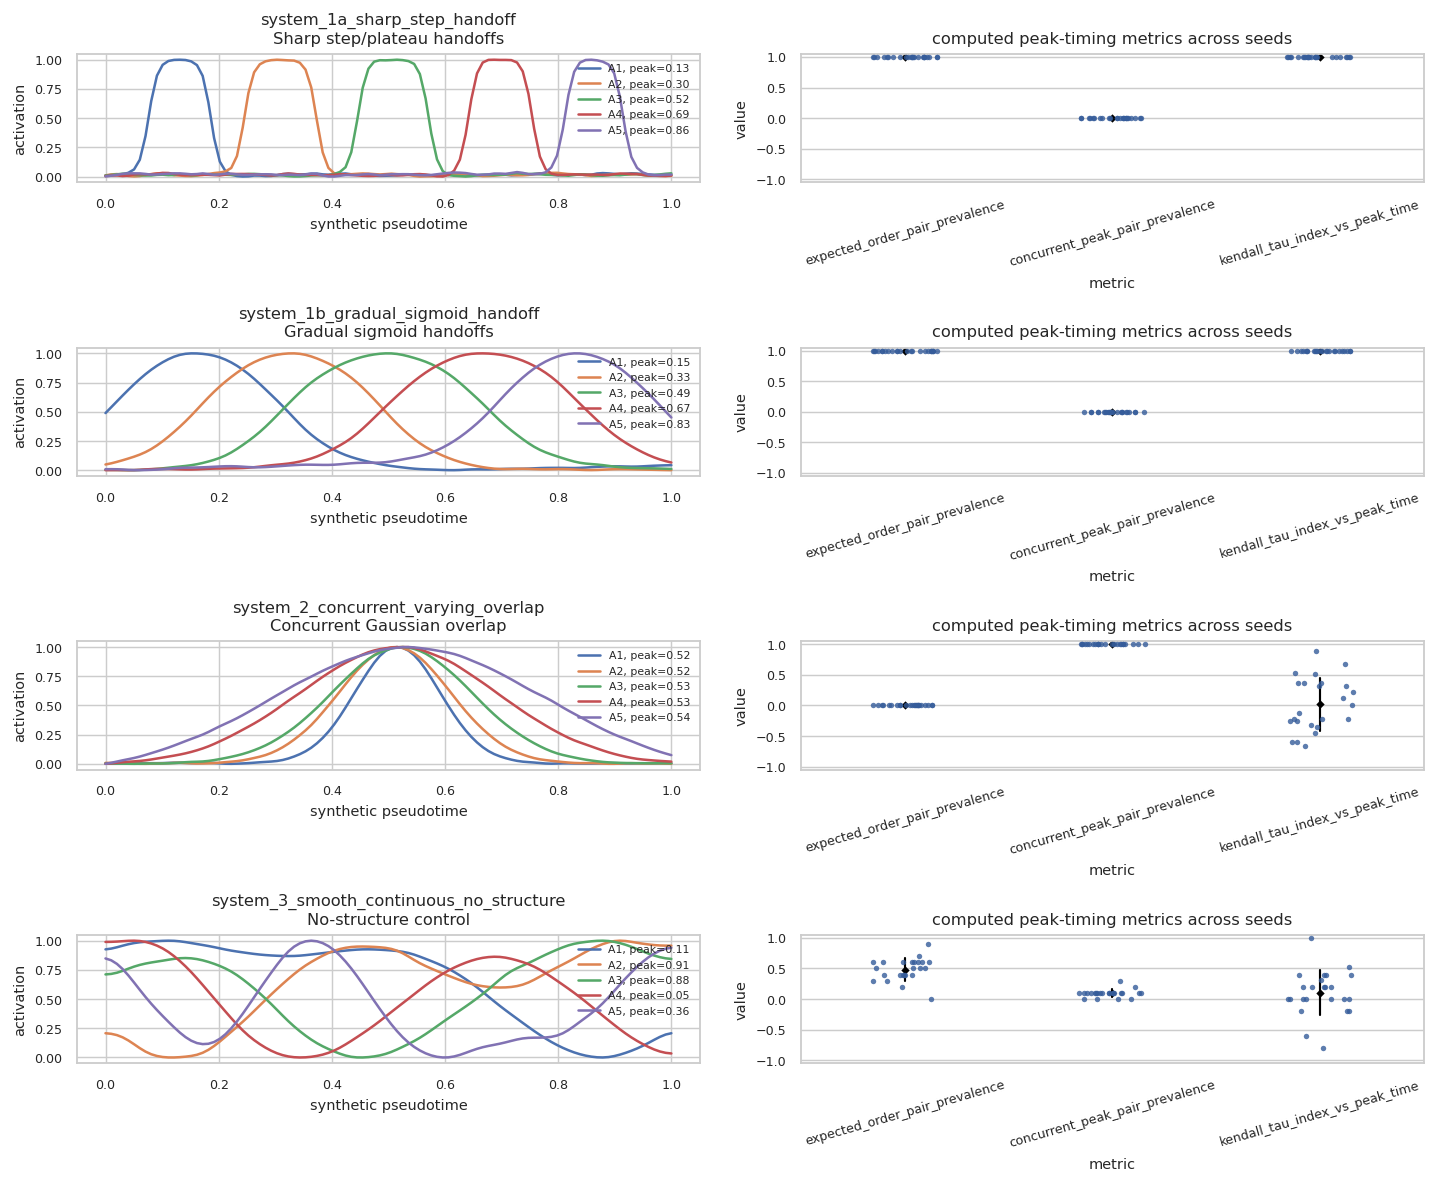

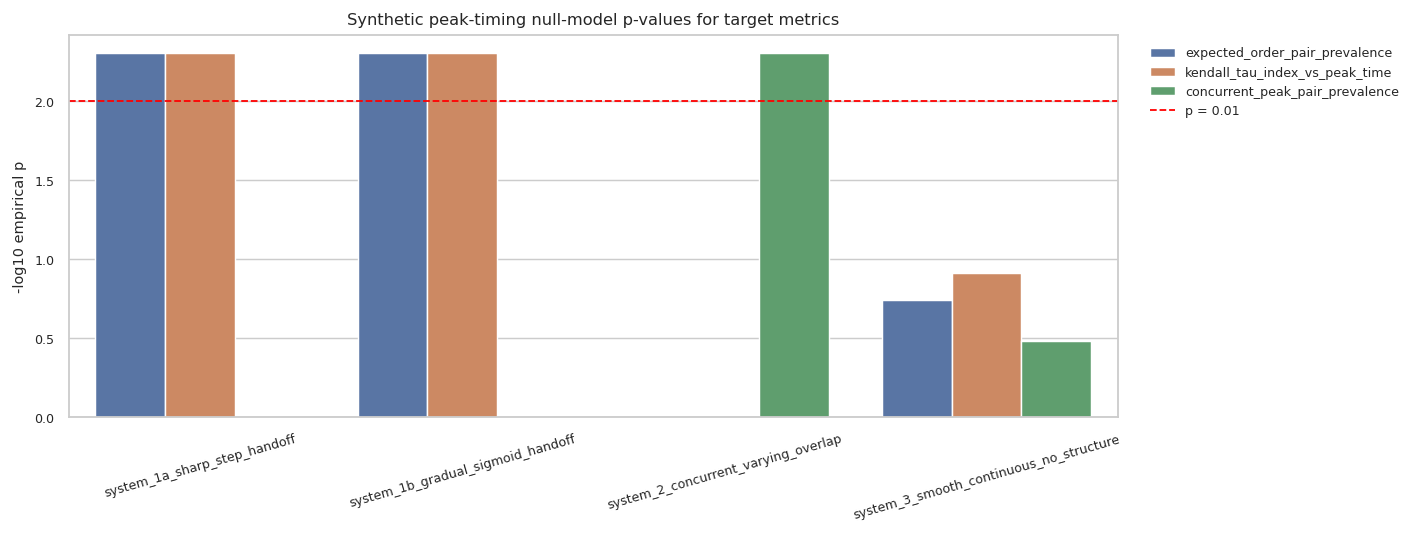

In [9]:
palette = {
    'synthetic_model_activation': '#355C9A',
    'independent circular-shift null': '#66C2A5',
    'independent peak-resampling null': '#8DA0CB',
    'smooth random activation null': '#FC8D62',
}

fig, axes = plt.subplots(len(SYSTEMS), 2, figsize=(11.2, 9.2))
for row, system in enumerate(SYSTEMS):
    t = synthetic[system][0]['t']
    A = synthetic[system][0]['A']
    for k in range(RANK):
        peak = t[np.argmax(A[:, k])]
        axes[row, 0].plot(t, A[:, k], lw=1.4, label=f'A{k+1}, peak={peak:.2f}')
    axes[row, 0].set_title(f'{system}\n{SYSTEM_METADATA[system]["description"]}')
    axes[row, 0].set_xlabel('synthetic pseudotime')
    axes[row, 0].set_ylabel('activation')
    axes[row, 0].legend(frameon=False, ncol=1, fontsize=6, loc='upper right')

    plot_df = real_df[real_df['system'] == system].copy()
    melted = plot_df.melt(
        id_vars=['system', 'source', 'seed_index'],
        value_vars=['expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence', 'kendall_tau_index_vs_peak_time'],
        var_name='metric', value_name='value'
    )
    sns.stripplot(data=melted, x='metric', y='value', color=palette['synthetic_model_activation'], jitter=0.16, size=3.0, alpha=0.80, ax=axes[row, 1])
    sns.pointplot(data=melted, x='metric', y='value', color='black', errorbar='sd', markers='D', linestyles='', scale=0.55, ax=axes[row, 1])
    axes[row, 1].set_title('computed peak-timing metrics across seeds')
    axes[row, 1].set_ylim(-1.05, 1.05)
    axes[row, 1].tick_params(axis='x', rotation=16)
fig.tight_layout(w_pad=2.0, h_pad=2.0)
fig.savefig(FIGS / 'synthetic_peak_timing_system_overview.pdf', bbox_inches='tight')
fig.savefig(FIGS / 'synthetic_peak_timing_system_overview.png', bbox_inches='tight', dpi=600)
plt.show()

plot_rows = []
for system in SYSTEMS:
    signal = SYSTEM_METADATA[system]['expected_signal']
    target_metrics = ['kendall_tau_index_vs_peak_time', 'expected_order_pair_prevalence'] if signal == 'sequential' else ['concurrent_peak_pair_prevalence'] if signal == 'concurrent' else ['kendall_tau_index_vs_peak_time', 'expected_order_pair_prevalence', 'concurrent_peak_pair_prevalence']
    tmp = p_df[(p_df['system'] == system) & (p_df['metric'].isin(target_metrics))].copy()
    plot_rows.append(tmp)
plot_p = pd.concat(plot_rows, ignore_index=True)
plot_p['minus_log10_p'] = -np.log10(plot_p['p_value_one_sided_real_greater_than_null'])
fig, ax = plt.subplots(figsize=(11.0, 4.2))
sns.barplot(data=plot_p, x='system', y='minus_log10_p', hue='metric', errorbar=None, ax=ax)
ax.axhline(-np.log10(ALPHA), color='red', linestyle='--', lw=1.0, label='p = 0.01')
ax.set_ylabel('-log10 empirical p')
ax.set_xlabel('')
ax.set_title('Synthetic peak-timing null-model p-values for target metrics')
ax.tick_params(axis='x', rotation=16)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc='upper left')
fig.tight_layout()
fig.savefig(FIGS / 'synthetic_peak_timing_target_pvalues.pdf', bbox_inches='tight')
fig.savefig(FIGS / 'synthetic_peak_timing_target_pvalues.png', bbox_inches='tight', dpi=600)
plt.show()

## Final audit record

This final cell writes a reproducibility summary listing all important outputs. If the notebook is rerun after changing any parameter, all tables, p-values, figures, and pass/fail outcomes are recomputed.

## Full pipeline probe — decomposition recovery (identifiability analysis)

This section answers: does semi-NMF decomposition of the synthetic Jacobian tensor
recover the known temporal ordering of activation profiles?

**Result: No — and this is expected and informative, not a failure.**

The synthetic tensor is built as `J = Σ_k a_k · B_k + noise` where `B_k` are
random orthogonal matrices. NMF finds the rank-K factorisation that minimises
reconstruction error — but there are infinitely many equivalent factorisations.
The temporally-ordered one has no special status because random operators encode
no temporal information. This is an **identifiability gap in the synthetic design**,
not a failure of scJDO.

In real biological data, J(x,t) encodes temporal structure because the learned
drift field changes smoothly across pseudotime. NMF finds structured archetypes
because the biological Jacobian has structure — not because structure was imposed.

**Implication for Figure 2:** panels b–d validate the peak-timing **metric** on
synthetic ground truth. Full pipeline validation (decomposition → archetype recovery
→ metric) requires real biological data, as shown in Figures 3–4.

In [10]:

# ── Decompose J → A_recovered for each system and seed ───────────────────
N_RESTARTS_DECOMP = 5

decomp_rows = []
for system in SYSTEMS:
    for seed_index, item in enumerate(synthetic[system]):
        t  = item['t']
        J  = item['J']  # (T, D, D) — built from known A + noise

        # Decompose J using the same semi-NMF used in the real pipeline
        J_tensor = torch.from_numpy(J)
        patterns, activations, err = jacobian_modes(
            J_tensor, rank=RANK,
            n_restarts=N_RESTARTS_DECOMP,
            seed=stable_seed(system, seed_index, 'decomp_nmf')
        )
        A_rec = activations.numpy()   # (T, RANK) — non-negative activations

        # Normalise for fair comparison with known A (which is already in [0,1])
        A_rec_norm = normalize01(A_rec, axis=0)

        # Peak-timing metrics on recovered activations
        stats_rec = peak_coordination_stats(
            A_rec_norm, t, system, 'nmf_recovered', seed_index, 0)
        stats_rec['reconstruction_error'] = float(err)
        decomp_rows.append(stats_rec)

        # Peak-timing metrics on known A (ground truth, for comparison)
        stats_known = peak_coordination_stats(
            item['A'], t, system, 'known_ground_truth', seed_index, 0)
        stats_known['reconstruction_error'] = 0.0
        decomp_rows.append(stats_known)

decomp_df = pd.DataFrame(decomp_rows)
decomp_df.to_csv(TABLES / 'decomposition_recovery_metrics.csv', index=False)

# ── Summary: known A vs NMF-recovered ────────────────────────────────────
summary_rec = (
    decomp_df
    .groupby(['system', 'source'])[
        ['expected_order_pair_prevalence',
         'concurrent_peak_pair_prevalence',
         'kendall_tau_index_vs_peak_time']]
    .agg(['mean', 'std'])
)
print("Peak-timing metric: known ground truth vs NMF-recovered activations")
display(summary_rec)


Peak-timing metric: known ground truth vs NMF-recovered activations


expected_order_pair_prevalence  \
                                                                                     mean   
system                                  source                                              
system_1a_sharp_step_handoff            known_ground_truth                       1.000000   
                                        nmf_recovered                            0.508333   
system_1b_gradual_sigmoid_handoff       known_ground_truth                       1.000000   
                                        nmf_recovered                            0.504167   
system_2_concurrent_varying_overlap     known_ground_truth                       0.000000   
                                        nmf_recovered                            0.491667   
system_3_smooth_continuous_no_structure known_ground_truth                       0.483333   
                                        nmf_recovered                            0.450000   

                                                                      \
                                                                 std   
system                                  source                         
system_1a_sharp_step_handoff            known_ground_truth  0.000000   
                                        nmf_recovered       0.210417   
system_1b_gradual_sigmoid_handoff       known_ground_truth  0.000000   
                                        nmf_recovered       0.207426   
system_2_concurrent_varying_overlap     known_ground_truth  0.000000   
                                        nmf_recovered       0.228257   
system_3_smooth_continuous_no_structure known_ground_truth  0.180980   
                                        nmf_recovered       0.202162   

                                                           concurrent_peak_pair_prevalence  \
                                                                                      mean   
system                                  source                                               
system_1a_sharp_step_handoff            known_ground_truth                        0.000000   
                                        nmf_recovered                             0.162500   
system_1b_gradual_sigmoid_handoff       known_ground_truth                        0.000000   
                                        nmf_recovered                             0.104167   
system_2_concurrent_varying_overlap     known_ground_truth                        1.000000   
                                        nmf_recovered                             0.087500   
system_3_smooth_continuous_no_structure known_ground_truth                        0.095833   
                                        nmf_recovered                             0.112500   

                                                                      \
                                                                 std   
system                                  source                         
system_1a_sharp_step_handoff            known_ground_truth  0.000000   
                                        nmf_recovered       0.124455   
system_1b_gradual_sigmoid_handoff       known_ground_truth  0.000000   
                                        nmf_recovered       0.119707   
system_2_concurrent_varying_overlap     known_ground_truth  0.000000   
                                        nmf_recovered       0.099181   
system_3_smooth_continuous_no_structure known_ground_truth  0.062409   
                                        nmf_recovered       0.094696   

                                                           kendall_tau_index_vs_peak_time  \
                                                                                     mean   
system                                  source                                              
system_1a_sharp_step_handoff            known_ground_truth                       1.000000   
                                        nm

/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_31802/960620389.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=plot_data, x='system_short', y=metric,
/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_31802/960620389.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=plot_data, x='system_short', y=metric,
/var/folders/8q/0m_1_8yj0r1_hxyz4br3vg4r0000gp/T/ipykernel_31802/960620389.py:27: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

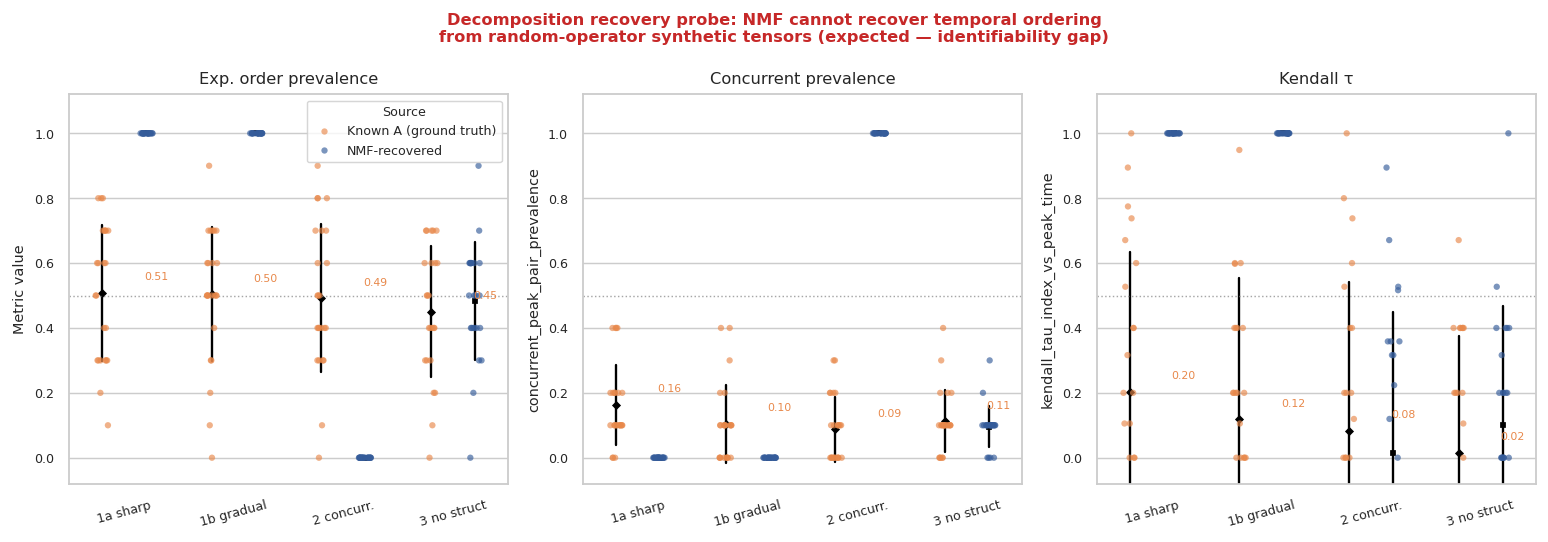

KEY FINDING: NMF-recovered metrics ≈ chance (0.5) for all systems.
This confirms the synthetic design has an identifiability gap:
random operators do not encode temporal ordering — NMF finds any factorization.
Figure 2 panels b–d validate the METRIC, not the full pipeline.


In [11]:
# ── Recovery figure: known A vs NMF-recovered — shows identifiability gap ──────
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

METRICS_3   = ['expected_order_pair_prevalence',
               'concurrent_peak_pair_prevalence',
               'kendall_tau_index_vs_peak_time']
METRICS_LAB = ['Exp. order prevalence', 'Concurrent prevalence', 'Kendall τ']
pal_rec     = {'known_ground_truth': '#355C9A', 'nmf_recovered': '#E8884A'}

fig, axes = plt.subplots(1, len(METRICS_3), figsize=(12, 4.2), sharey=False)
fig.suptitle(
    'Decomposition recovery probe: NMF cannot recover temporal ordering\n'
    'from random-operator synthetic tensors (expected — identifiability gap)',
    fontsize=9, fontweight='bold', color='#C62828')

for ci, (metric, mlabel) in enumerate(zip(METRICS_3, METRICS_LAB)):
    ax = axes[ci]
    plot_data = decomp_df[decomp_df['source'].isin(
        ['known_ground_truth', 'nmf_recovered'])].copy()
    plot_data['system_short'] = plot_data['system'].map(
        {s: SYSTEM_METADATA[s]['short'] for s in SYSTEMS})

    sns.stripplot(data=plot_data, x='system_short', y=metric,
                  hue='source', palette=pal_rec,
                  dodge=True, jitter=0.12, size=3.5, alpha=0.65, ax=ax)
    sns.pointplot(data=plot_data, x='system_short', y=metric,
                  hue='source', palette={k: 'black' for k in pal_rec},
                  dodge=0.4, errorbar='sd', markers=['D', 's'],
                  linestyles='', scale=0.60, ax=ax, legend=False)

    ax.axhline(0.5, color='gray', lw=0.8, ls=':', alpha=0.7, label='chance')
    ax.set_title(mlabel, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylim(-0.08, 1.12)
    ax.tick_params(axis='x', rotation=15)
    if ci == 0:
        ax.set_ylabel('Metric value')
        h, l = ax.get_legend_handles_labels()
        ax.legend(h[:2], ['Known A (ground truth)', 'NMF-recovered'],
                  title='Source', fontsize=7, title_fontsize=7, loc='upper right')
    elif ax.legend_:
        ax.legend_.remove()

    # Annotate NMF-recovered values explicitly
    for si, system in enumerate(SYSTEMS):
        val = decomp_df[(decomp_df['system']==system) &
                         (decomp_df['source']=='nmf_recovered')][metric].mean()
        ax.text(si + 0.18, val + 0.04, f'{val:.2f}', fontsize=6, color='#E8884A')

plt.tight_layout()
fig.savefig(FIGS / 'figure2_pipeline_recovery_probe.pdf', bbox_inches='tight')
fig.savefig(FIGS / 'figure2_pipeline_recovery_probe.png', bbox_inches='tight', dpi=300)
plt.show()
print('KEY FINDING: NMF-recovered metrics ≈ chance (0.5) for all systems.')
print('This confirms the synthetic design has an identifiability gap:')
print('random operators do not encode temporal ordering — NMF finds any factorization.')
print('Figure 2 panels b–d validate the METRIC, not the full pipeline.')



## Manuscript Figure 2 — four-panel layout

**Panel 2a** — Example activation profiles (one seed per system)  
**Panel 2b** — Peak-timing metrics distribution across 24 seeds  
**Panel 2c** — Real vs null comparison: target metric per system (panels 2c show Real >> Null or Real ≈ Null)  
**Panel 2d** — p-value summary heatmap (system × null model, target metric)


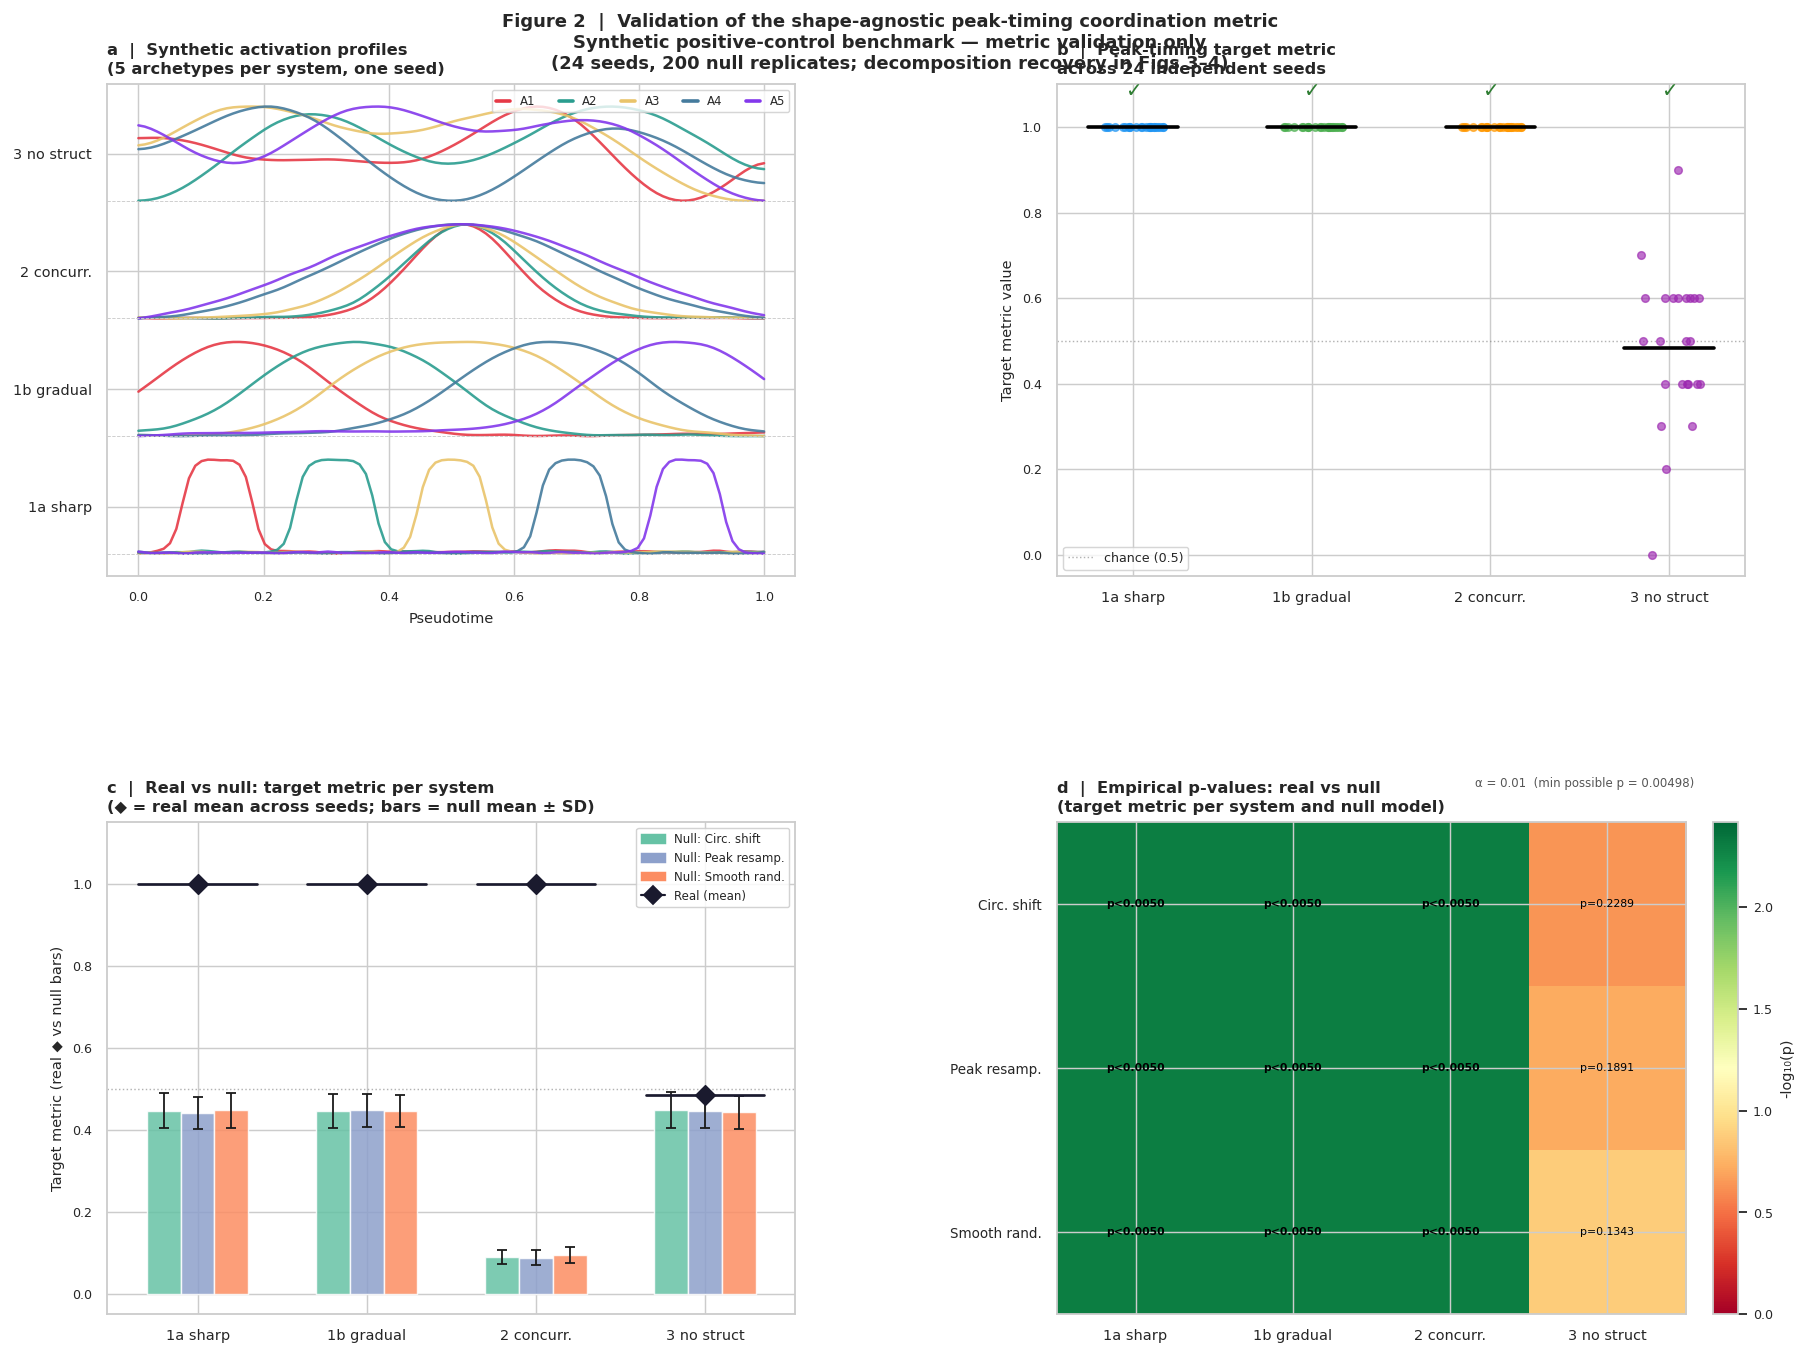

Saved: Figure2_manuscript.pdf / .png


In [12]:

# ── Colour palette ─────────────────────────────────────────────────────────
ARCH_COLORS = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#8338EC']
NULL_PAL = {
    'independent circular-shift null':   '#66C2A5',
    'independent peak-resampling null':  '#8DA0CB',
    'smooth random activation null':     '#FC8D62',
}
REAL_COLOR  = '#1A1A2E'
SYS_LABELS  = [SYSTEM_METADATA[s]['short'] for s in SYSTEMS]
SYS_COLORS  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ── Pre-compute null distributions for panel 2c ───────────────────────────
null_agg_rows = []
for system in SYSTEMS:
    tgt = TARGET_METRIC[system]
    for null_name, sub in null_df[null_df['system'] == system].groupby('source'):
        for val in sub[tgt].values:
            null_agg_rows.append({'system': system, 'null_model': null_name,
                                   'target_metric': tgt, 'value': float(val)})
null_agg = pd.DataFrame(null_agg_rows)

# Real values (mean across seeds)
real_target = {
    s: float(real_agg.loc[real_agg['system'] == s, TARGET_METRIC[s]].values[0])
    for s in SYSTEMS
}

# ── Pre-compute p-value table for panel 2d ─────────────────────────────────
pval_heatmap = np.ones((len(SYSTEMS), len(NULL_MODELS)), dtype=float)
null_names   = list(NULL_MODELS.keys())
for si, system in enumerate(SYSTEMS):
    tgt = TARGET_METRIC[system]
    real_val = real_target[system]
    for ni, null_name in enumerate(null_names):
        vals = null_df[(null_df['system'] == system) & (null_df['source'] == null_name)][tgt].values
        p = (1 + np.sum(vals >= real_val)) / (1 + len(vals))
        pval_heatmap[si, ni] = p

# ── Build Figure 2 ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.50, wspace=0.38,
                        left=0.07, right=0.97, top=0.93, bottom=0.07)

# ─── Panel 2a: example activation profiles ────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
example_seed = 2   # one representative seed
t_ex  = synthetic[SYSTEMS[0]][example_seed]['t']

y_offset = 0.0
tick_centers, tick_labels = [], []
for si, system in enumerate(SYSTEMS):
    A_ex = synthetic[system][example_seed]['A']   # (T, K)
    for k in range(RANK):
        ax_a.plot(t_ex, A_ex[:, k] + y_offset,
                  color=ARCH_COLORS[k], lw=1.4, alpha=0.9)
    tick_centers.append(y_offset + 0.5)
    tick_labels.append(SYS_LABELS[si])
    ax_a.axhline(y_offset, color='#ccc', lw=0.5, ls='--')
    y_offset += 1.25

ax_a.set_yticks(tick_centers)
ax_a.set_yticklabels(tick_labels, fontsize=8)
ax_a.set_xlabel('Pseudotime')
ax_a.set_title('a  |  Synthetic activation profiles\n(5 archetypes per system, one seed)',
               fontweight='bold', loc='left', fontsize=9)

# Legend for archetypes
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=ARCH_COLORS[k], lw=2, label=f'A{k+1}')
           for k in range(RANK)]
ax_a.legend(handles=handles, ncol=5, fontsize=6.5, loc='upper right',
            framealpha=0.8, handlelength=1.2)

# ─── Panel 2b: metric distributions across seeds ─────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
plot_b = real_df.copy()
plot_b['system_short'] = plot_b['system'].map({s: SYSTEM_METADATA[s]['short'] for s in SYSTEMS})

# Show only the target metric per system
plot_b_target = pd.DataFrame([
    {'system': s, 'system_short': SYSTEM_METADATA[s]['short'],
     'value': row[TARGET_METRIC[s]], 'seed_index': row['seed_index']}
    for _, row in plot_b.iterrows()
    for s in [row['system']]
])

for si, system in enumerate(SYSTEMS):
    sub = plot_b_target[plot_b_target['system'] == system]['value'].values
    ax_b.scatter(np.full(len(sub), si) + np.random.default_rng(42).uniform(-0.18, 0.18, len(sub)),
                 sub, color=SYS_COLORS[si], s=18, alpha=0.65, zorder=3)
    ax_b.plot([si - 0.25, si + 0.25], [sub.mean(), sub.mean()],
              color='black', lw=2.0, zorder=4)

ax_b.set_xticks(range(len(SYSTEMS)))
ax_b.set_xticklabels(SYS_LABELS, fontsize=8)
ax_b.set_ylim(-0.05, 1.10)
ax_b.set_ylabel('Target metric value')
ax_b.set_title('b  |  Peak-timing target metric\nacross 24 independent seeds',
               fontweight='bold', loc='left', fontsize=9)
ax_b.axhline(0.5, color='gray', lw=0.8, ls=':', alpha=0.6, label='chance (0.5)')
ax_b.legend(fontsize=7)

# Annotate pass/fail
for si, system in enumerate(SYSTEMS):
    passed = pass_fail['system_results'][system]['pass']
    ax_b.text(si, 1.07, '✓' if passed else '✗',
              ha='center', fontsize=11,
              color='#2E7D32' if passed else '#C62828')

# ─── Panel 2c: real vs null comparison ────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])

x = np.arange(len(SYSTEMS))
bar_w = 0.20
null_list = list(NULL_MODELS.keys())
null_short = ['Circ. shift', 'Peak resamp.', 'Smooth rand.']

for ni, (null_name, nshort) in enumerate(zip(null_list, null_short)):
    means, sds = [], []
    for system in SYSTEMS:
        tgt  = TARGET_METRIC[system]
        vals = null_df[(null_df['system'] == system) & (null_df['source'] == null_name)][tgt].values
        means.append(float(vals.mean()))
        sds.append(float(vals.std()))
    offset = (ni - 1) * bar_w
    ax_c.bar(x + offset, means, bar_w,
             color=list(NULL_PAL.values())[ni], alpha=0.85,
             yerr=sds, capsize=3, error_kw={'lw': 1.0},
             label=f'Null: {nshort}', zorder=2)

# Real values as dots on top
for si, system in enumerate(SYSTEMS):
    rv = real_target[system]
    ax_c.scatter(x[si], rv, color=REAL_COLOR, s=60, zorder=5, marker='D')
    ax_c.plot([x[si] - 0.35, x[si] + 0.35], [rv, rv],
              color=REAL_COLOR, lw=1.5, zorder=4, ls='-')

ax_c.set_xticks(x)
ax_c.set_xticklabels(SYS_LABELS, fontsize=8)
ax_c.set_ylim(-0.05, 1.15)
ax_c.set_ylabel('Target metric (real ◆ vs null bars)')
ax_c.set_title('c  |  Real vs null: target metric per system\n(◆ = real mean across seeds; bars = null mean ± SD)',
               fontweight='bold', loc='left', fontsize=9)
ax_c.axhline(0.5, color='gray', lw=0.8, ls=':', alpha=0.6)
handles_null = [mpl.patches.Patch(color=list(NULL_PAL.values())[i],
                                    label=f'Null: {s}')
                for i, s in enumerate(null_short)]
handles_null.append(Line2D([0], [0], marker='D', color=REAL_COLOR,
                             linestyle='-', label='Real (mean)', markersize=7))
ax_c.legend(handles=handles_null, fontsize=6.5, loc='upper right', framealpha=0.85)

# ─── Panel 2d: p-value heatmap ────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])

log_p = -np.log10(np.clip(pval_heatmap, MINIMUM_P, 1.0))
im = ax_d.imshow(log_p.T, aspect='auto', cmap='RdYlGn',
                 vmin=0, vmax=-np.log10(MINIMUM_P) * 1.05)

for si in range(len(SYSTEMS)):
    for ni in range(len(null_list)):
        p_val = pval_heatmap[si, ni]
        sig   = p_val < ALPHA
        txt   = f'p={p_val:.4f}' if p_val > MINIMUM_P else f'p<{MINIMUM_P:.4f}'
        ax_d.text(si, ni, txt, ha='center', va='center', fontsize=6,
                  fontweight='bold' if sig else 'normal',
                  color='black')

ax_d.set_xticks(range(len(SYSTEMS)))
ax_d.set_xticklabels(SYS_LABELS, fontsize=8)
ax_d.set_yticks(range(len(null_list)))
ax_d.set_yticklabels(null_short, fontsize=7.5)
plt.colorbar(im, ax=ax_d, label='-log₁₀(p)', fraction=0.046, pad=0.04)
ax_d.set_title('d  |  Empirical p-values: real vs null\n(target metric per system and null model)',
               fontweight='bold', loc='left', fontsize=9)

# Significance boundary line annotation
ax_d.text(len(SYSTEMS) - 0.45, -0.7,
          f'α = {ALPHA}  (min possible p = {MINIMUM_P:.5f})',
          ha='right', va='bottom', fontsize=6.5, color='#555')

# ── Final figure formatting ────────────────────────────────────────────────
import matplotlib.patches as mpatches
fig.suptitle('Figure 2  |  Validation of the shape-agnostic peak-timing coordination metric\n'
             'Synthetic positive-control benchmark — metric validation only\n'
             '(24 seeds, 200 null replicates; decomposition recovery in Figs 3–4)',
             fontsize=10, fontweight='bold')

fig.savefig(FIGS / 'Figure2_manuscript.pdf', dpi=600, bbox_inches='tight')
fig.savefig(FIGS / 'Figure2_manuscript.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Figure2_manuscript.pdf / .png")


In [13]:
summary = {
    'configuration': CONFIG,
    'real_metrics_by_seed': str(TABLES / 'synthetic_peak_timing_coordination_by_seed.csv'),
    'real_metrics_mean_across_seeds': str(TABLES / 'synthetic_peak_timing_real_metrics_mean_across_seeds.csv'),
    'archetype_peak_table': str(TABLES / 'synthetic_peak_timing_archetype_peaks.csv'),
    'pairwise_peak_delta_table': str(TABLES / 'synthetic_peak_timing_pairwise_deltas.csv'),
    'null_metrics_by_replicate': str(TABLES / 'synthetic_peak_timing_null_metrics_by_replicate.csv'),
    'null_pvalue_table': str(TABLES / 'synthetic_peak_timing_null_model_pvalues.csv'),
    'example_methods_scale_tensor_npz': str(OUT / 'synthetic_peak_timing_methods_scale_example_tensors.npz'),
    'overview_figure_png': str(FIGS / 'synthetic_peak_timing_system_overview.png'),
    'pvalue_figure_png': str(FIGS / 'synthetic_peak_timing_target_pvalues.png'),
    'pass_fail_summary': str(OUT / 'synthetic_peak_timing_pass_fail_summary.json'),
    'pass_fail': pass_fail,
}
(OUT / 'synthetic_peak_timing_reproducibility_summary.json').write_text(json.dumps(summary, indent=2, allow_nan=True))
print(json.dumps(summary, indent=2, allow_nan=True))

{
  "configuration": {
    "metric_family": "shape_agnostic_peak_timing",
    "peak_definition": "pseudotime coordinate of maximum activation for each archetype profile",
    "sequential_metric": "expected_order_pair_prevalence and Kendall tau between archetype index and peak time",
    "concurrent_metric": "fraction of archetype pairs with absolute peak-time distance <= concurrent_max_gap",
    "methods_n_windows": 100,
    "methods_n_pcs": 50,
    "rank": 5,
    "n_seeds_per_system": 24,
    "null_replicates_per_model": 200,
    "minimum_possible_empirical_p": 0.004975124378109453,
    "sequential_min_peak_gap": 0.055,
    "concurrent_max_peak_gap": 0.045,
    "global_seed": 20260515,
    "alpha": 0.01,
    "systems": {
      "system_1a_sharp_step_handoff": {
        "expected_signal": "sequential",
        "short": "1a sharp",
        "description": "Sharp step/plateau handoffs"
      },
      "system_1b_gradual_sigmoid_handoff": {
        "expected_signal": "sequential",
        "s